##### Analysing Data

In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"K-means\Customer_Segmentation\data.csv", encoding = 'latin1')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [18]:
df.drop(columns = ['Description', 'StockCode'], inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   Quantity     541909 non-null  int64         
 2   InvoiceDate  541909 non-null  datetime64[ns]
 3   UnitPrice    541909 non-null  float64       
 4   CustomerID   406829 non-null  float64       
 5   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 24.8+ MB


###### We need to create features in order to segment customer on the basic of "PAID_PRICE", "FREQUENCY OF PURCHASE" and "RECENCY"

In [19]:
df['Paid_price'] = df['Quantity']*df['UnitPrice']

customer_df = df.groupby("CustomerID").agg(TotalAmount = ("Paid_price", "sum"),
                                           Frequency = ("InvoiceNo", "nunique"),
                                           LastPurchase = ("InvoiceDate", "max")).reset_index()


reference_date = customer_df["LastPurchase"].max()

customer_df["Recency_days"] = (reference_date - customer_df['LastPurchase']).dt.days

print(customer_df.head())
customer_df.info()

   CustomerID  TotalAmount  Frequency        LastPurchase  Recency_days
0     12346.0         0.00          2 2011-01-18 10:17:00           325
1     12347.0      4310.00          7 2011-12-07 15:52:00             1
2     12348.0      1797.24          4 2011-09-25 13:13:00            74
3     12349.0      1757.55          1 2011-11-21 09:51:00            18
4     12350.0       334.40          1 2011-02-02 16:01:00           309
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   CustomerID    4372 non-null   float64       
 1   TotalAmount   4372 non-null   float64       
 2   Frequency     4372 non-null   int64         
 3   LastPurchase  4372 non-null   datetime64[ns]
 4   Recency_days  4372 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 170.9 KB


In [20]:
customer_df['TotalAmount'] = np.log1p(customer_df['TotalAmount'])
customer_df['Frequency'] = np.log1p(customer_df['TotalAmount'])
customer_df['Recency_days'] = np.log1p(customer_df['TotalAmount'])

customer_df.dropna(inplace = True)
print(customer_df.isna().sum())
features = ['TotalAmount', 'Frequency', 'Recency_days']
X = customer_df[features]

CustomerID      0
TotalAmount     0
Frequency       0
LastPurchase    0
Recency_days    0
dtype: int64


c:\users\lenovo\.pyenv\pyenv-win\versions\3.7.4\lib\site-packages\pandas\core\arraylike.py:364: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

scaler = StandardScaler()
kmeans = KMeans(n_clusters = 4, random_state = 23)

preprocessor = ColumnTransformer(transformers = [('Preprocess', scaler, features)])
model = Pipeline(steps = [('preprocess', preprocessor),
                          ('model', kmeans)])


In [22]:
model.fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

In [23]:
customer_trained = customer_df.copy()
customer_trained['Cluster'] = labels
customer_trained.head()

,CustomerID,TotalAmount,Frequency,LastPurchase,Recency_days,Cluster
0,12346.0,0.000000,0.000000,2011-01-18 10:17:00,0.000000,3
1,12347.0,8.368925,2.237398,2011-12-07 15:52:00,2.237398,2
2,12348.0,7.494564,2.139426,2011-09-25 13:13:00,2.139426,2
3,12349.0,7.472245,2.136796,2011-11-21 09:51:00,2.136796,2
4,12350.0,5.815324,1.919174,2011-02-02 16:01:00,1.919174,0


In [24]:
from sklearn.decomposition import PCA


pca = PCA(n_components = 2)
x_pca = pca.fit_transform(X)

customer_trained['pca1'] = x_pca[:,0]
customer_trained['pca2'] = x_pca[:,1]
customer_trained.head()

,CustomerID,TotalAmount,Frequency,LastPurchase,Recency_days,Cluster,pca1,pca2
0,12346.0,0.000000,0.000000,2011-01-18 10:17:00,0.000000,3,6.991780,1.439684
1,12347.0,8.368925,2.237398,2011-12-07 15:52:00,2.237398,2,-1.846438,0.048025
2,12348.0,7.494564,2.139426,2011-09-25 13:13:00,2.139426,2,-0.962193,0.005425
3,12349.0,7.472245,2.136796,2011-11-21 09:51:00,2.136796,2,-0.939584,0.004517
4,12350.0,5.815324,1.919174,2011-02-02 16:01:00,1.919174,0,0.745283,-0.031955


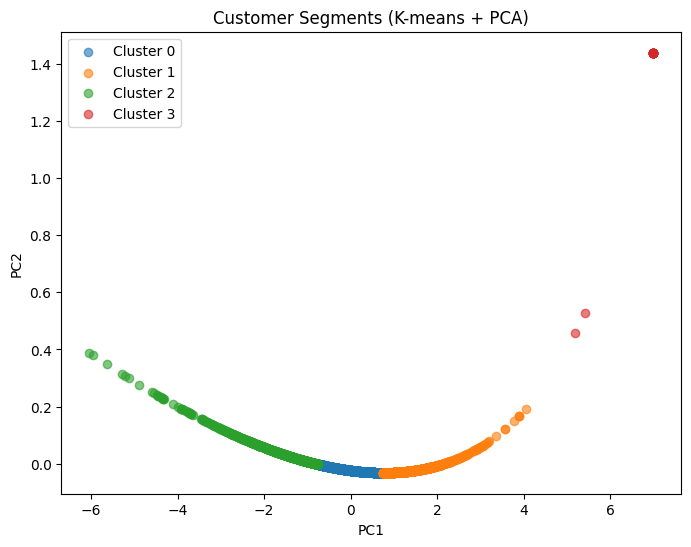

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for c in sorted(customer_trained["Cluster"].unique()):
    subset = customer_trained[customer_trained["Cluster"] == c]
    plt.scatter(
        subset["pca1"],
        subset["pca2"],
        label=f"Cluster {c}",
        alpha=0.6,
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (K-means + PCA)")
plt.legend()
plt.show()

In [32]:
from sklearn.metrics import silhouette_score
X_scaled = scaler.fit_transform(X)  
for k in range(2,10):
    km = KMeans(n_clusters = k, random_state = 23)
    km.fit(X_scaled)
    score = silhouette_score(X_scaled, km.labels_)
    print(f"k: {k}\nsilhoutte_score: {score}")

k: 2
silhoutte_score: 0.5455050936070877
k: 3
silhoutte_score: 0.5607676192635325
k: 4
silhoutte_score: 0.5237235856485409
k: 5
silhoutte_score: 0.5220522422818433
k: 6
silhoutte_score: 0.5232376347375618
k: 7
silhoutte_score: 0.5274896491256923
k: 8
silhoutte_score: 0.5299721494086631
k: 9
silhoutte_score: 0.528791388883517
